[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


📦 Predicción para un nuevo objeto:
   Peso: 60g, Volumen: 180cm³
   Tipo estimado: Plástico


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/clasificador_reciclaje.png'

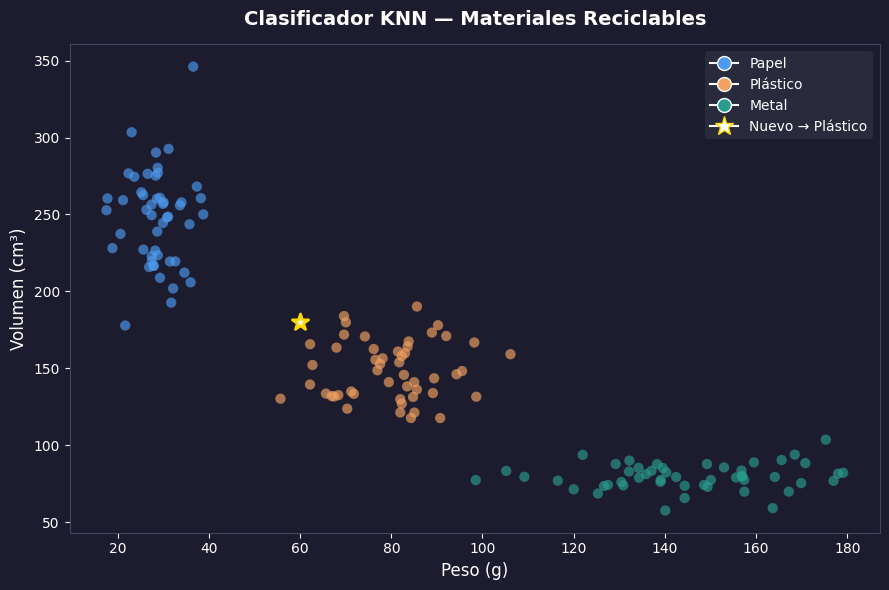

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Clase que representa un registro de reciclaje
class RecyclableItem:
    def __init__(self, weight, volume, material_type):
        self.weight = weight
        self.volume = volume
        self.material_type = material_type

    def to_vector(self):
        return [self.weight, self.volume]


# Generador de datos sintéticos
class RecyclingDataGenerator:
    def __init__(self, num_samples=150):
        self.num_samples = num_samples

    def generate(self):
        items = []
        n = self.num_samples // 3

        # Papel (0): peso ~30g, volumen ~250cm³
        for _ in range(n):
            weight = np.random.normal(30, 5)
            volume = np.random.normal(250, 30)
            items.append(RecyclableItem(weight, volume, 0))

        # Plástico (1): peso ~80g, volumen ~150cm³
        for _ in range(n):
            weight = np.random.normal(80, 10)
            volume = np.random.normal(150, 20)
            items.append(RecyclableItem(weight, volume, 1))

        # Metal (2): peso ~150g, volumen ~80cm³
        for _ in range(n):
            weight = np.random.normal(150, 20)
            volume = np.random.normal(80, 10)
            items.append(RecyclableItem(weight, volume, 2))

        return items


# Clasificador usando KNN
class RecyclableMaterialClassifier:
    def __init__(self, k=5):
        self.k = k
        self.model = KNeighborsClassifier(n_neighbors=k)

    def fit(self, records):
        X = [item.to_vector() for item in records]
        y = [item.material_type for item in records]
        self.model.fit(X, y)

    def predict(self, weight, volume):
        return self.model.predict([[weight, volume]])[0]

    def evaluate(self, records):
        X = [item.to_vector() for item in records]
        y = [item.material_type for item in records]
        y_pred = self.model.predict(X)
        print(confusion_matrix(y, y_pred))
        print(classification_report(y, y_pred))


# Clase de ejecución del ejemplo
class RecyclablePredictionExample:
    def run(self):
        # 1. Generar datos
        generator = RecyclingDataGenerator(num_samples=150)
        all_items = generator.generate()

        # 2. Separar en entrenamiento y prueba
        train_items, test_items = train_test_split(all_items, test_size=0.3, random_state=42)

        # 3. Entrenar el clasificador
        classifier = RecyclableMaterialClassifier(k=5)
        classifier.fit(train_items)

        # 4. Evaluar el rendimiento
        classifier.evaluate(test_items)

        # 5. Predicción para un nuevo objeto
        peso_nuevo = 60
        volumen_nuevo = 180
        prediccion = classifier.predict(peso_nuevo, volumen_nuevo)
        nombres = {0: "Papel", 1: "Plástico", 2: "Metal"}

        print("\n📦 Predicción para un nuevo objeto:")
        print(f"   Peso: {peso_nuevo}g, Volumen: {volumen_nuevo}cm³")
        print(f"   Tipo estimado: {nombres[prediccion]}")

        # 6. Visualización
        colores = {0: "#4E9AF1", 1: "#F4A261", 2: "#2A9D8F"}
        etiquetas = {0: "Papel", 1: "Plástico", 2: "Metal"}

        fig, ax = plt.subplots(figsize=(9, 6))
        fig.patch.set_facecolor("#1C1C2E")
        ax.set_facecolor("#1C1C2E")

        for item in all_items:
            ax.scatter(
                item.weight, item.volume,
                color=colores[item.material_type],
                alpha=0.65, edgecolors="none", s=55
            )

        # Punto nuevo
        ax.scatter(
            peso_nuevo, volumen_nuevo,
            color="white", s=150, zorder=5,
            edgecolors="#FFD700", linewidths=2,
            marker="*", label=f"Nuevo objeto → {nombres[prediccion]}"
        )

        # Leyenda manual
        from matplotlib.lines import Line2D
        handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=colores[k],
                   markersize=10, label=etiquetas[k])
            for k in colores
        ]
        handles.append(
            Line2D([0], [0], marker='*', color='w', markerfacecolor='white',
                   markeredgecolor='#FFD700', markersize=14,
                   label=f"Nuevo → {nombres[prediccion]}")
        )
        ax.legend(handles=handles, facecolor="#2E2E42", edgecolor="none",
                  labelcolor="white", fontsize=10)

        ax.set_xlabel("Peso (g)", color="white", fontsize=12)
        ax.set_ylabel("Volumen (cm³)", color="white", fontsize=12)
        ax.set_title("Clasificador KNN — Materiales Reciclables", color="white",
                     fontsize=14, fontweight="bold", pad=14)
        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444460")

        plt.tight_layout()
        plt.savefig("/mnt/user-data/outputs/clasificador_reciclaje.png", dpi=150,
                    facecolor=fig.get_facecolor())
        plt.show()


# Ejecutar
example = RecyclablePredictionExample()
example.run()